# **Car Price Prediction(Using Multiple Linear Regression🚗)**

> ## **About Dataset**<br>
This dataset contains various features related to cars, including the year of manufacture, selling price, kilometers driven, fuel type, seller type, transmission type, number of previous owners, mileage, and engine specifications. These attributes provide valuable insights into the factors influencing car prices and can be used to develop predictive models for estimating the selling price of cars.

> ## **Data Load and Explore🧐**

In [1]:
# importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,ElasticNet,Lasso,Ridge
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error,r2_score,mean_absolute_error
import joblib

In [2]:
data = pd.read_csv(r'cardekho.csv')

In [3]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [4]:
print(f'Shape Of Data(row,col): {data.shape}')

Shape Of Data(row,col): (8128, 12)


In [5]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 1.2 MB
None


### **Inferance**
1. **Missing Value:**<br>
- Columns like `mileage`,`engine`,`max_power`,`seats` contains missing values.
- Missing value handling required. 
2. **Data Type Conversion:**<br>
- Column `seat` should be in *int/float* rather than *str*.
- Can do data conversion to reduce size.

> ## **Data Cleaning🧹**

In [6]:
# Missing values in each column.
print((data.isna().sum()*100)/len(data))

name                  0.000000
year                  0.000000
selling_price         0.000000
km_driven             0.000000
fuel                  0.000000
seller_type           0.000000
transmission          0.000000
owner                 0.000000
mileage(km/ltr/kg)    2.718996
engine                2.718996
max_power             2.645177
seats                 2.718996
dtype: float64


In [7]:
data[data['max_power'].isna()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
13,Maruti Swift 1.3 VXi,2007,200000,80000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN
31,Fiat Palio 1.2 ELX,2003,70000,50000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN
78,Tata Indica DLS,2003,50000,70000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN
87,Maruti Swift VDI BSIV W ABS,2015,475000,78000,Diesel,Dealer,Manual,First Owner,NaN,NaN,NaN,NaN
119,Maruti Swift VDI BSIV,2010,300000,120000,Diesel,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
7846,Toyota Qualis Fleet A3,2000,200000,100000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN
7996,Hyundai Santro LS zipPlus,2000,140000,50000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN
8009,Hyundai Santro Xing XS eRLX Euro III,2006,145000,80000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN
8068,Ford Figo Aspire Facelift,2017,580000,165000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN


### **Inferance**
- Only ~2.7% data is missing from these 3 columns,Which is < 5% we can drop these missing values. also the data is missing in contineous form not randomly.

In [8]:
data = data.dropna()
print(f'New Data Shape(After Removing NAN): {data.shape}')

New Data Shape(After Removing NAN): (7907, 12)


> **converting dtype of max_power column in float**

In [9]:
data['max_power'] = pd.to_numeric(data['max_power'].str.strip())

In [10]:
# keeping only first word of `name` column
data['name'] = data['name'].str.split(' ').str.get(0)

# converting dtype of seats column from float to int.
data['seats'] = data['seats'].astype('int8')

In [11]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5
2,Honda,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5


In [12]:
data.info()

<class 'pandas.DataFrame'>
Index: 7907 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7907 non-null   object 
 1   year                7907 non-null   int64  
 2   selling_price       7907 non-null   int64  
 3   km_driven           7907 non-null   int64  
 4   fuel                7907 non-null   str    
 5   seller_type         7907 non-null   str    
 6   transmission        7907 non-null   str    
 7   owner               7907 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7906 non-null   float64
 11  seats               7907 non-null   int8   
dtypes: float64(3), int64(3), int8(1), object(1), str(4)
memory usage: 1010.9+ KB


In [13]:
# 1 nan value is present in max_power
data.dropna(inplace=True)

In [14]:
# checking for duplicate values
print(f'Total Number of Duplicate Values {data.duplicated().sum()}')
print(f'Data Size After Dropping Duplicate records: {data.shape}')

Total Number of Duplicate Values 1208
Data Size After Dropping Duplicate records: (7906, 12)


> ## **Data Preprocessing**

In [15]:
num_features = data.select_dtypes(include='number').columns.to_list()
cat_features = data.select_dtypes(include='str').columns.to_list()
print('Numerical Features: ', num_features)
print('Categorical Features: ',cat_features)

Numerical Features:  ['year', 'selling_price', 'km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']
Categorical Features:  ['fuel', 'seller_type', 'transmission', 'owner']


> **Checking For Outliers Using IQR Method**

In [16]:
cap_features = ['km_driven','selling_price','mileage(km/ltr/kg)','engine','max_power']
Q1 = data[cap_features].quantile(0.25)
Q3 = data[cap_features].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
outlier_count = ((data[cap_features]<lower_limit) | (data[cap_features]>upper_limit)).sum()
outlier_count

km_driven              194
selling_price          598
mileage(km/ltr/kg)      24
engine                1183
max_power              564
dtype: int64

In [17]:
## capping 
data[cap_features] = np.where(data[cap_features] > upper_limit,upper_limit,np.where(data[cap_features]<lower_limit,lower_limit,data[cap_features]))

In [18]:
import math
n_cols= 3
n_rows = math.ceil(len(num_features)/n_cols)

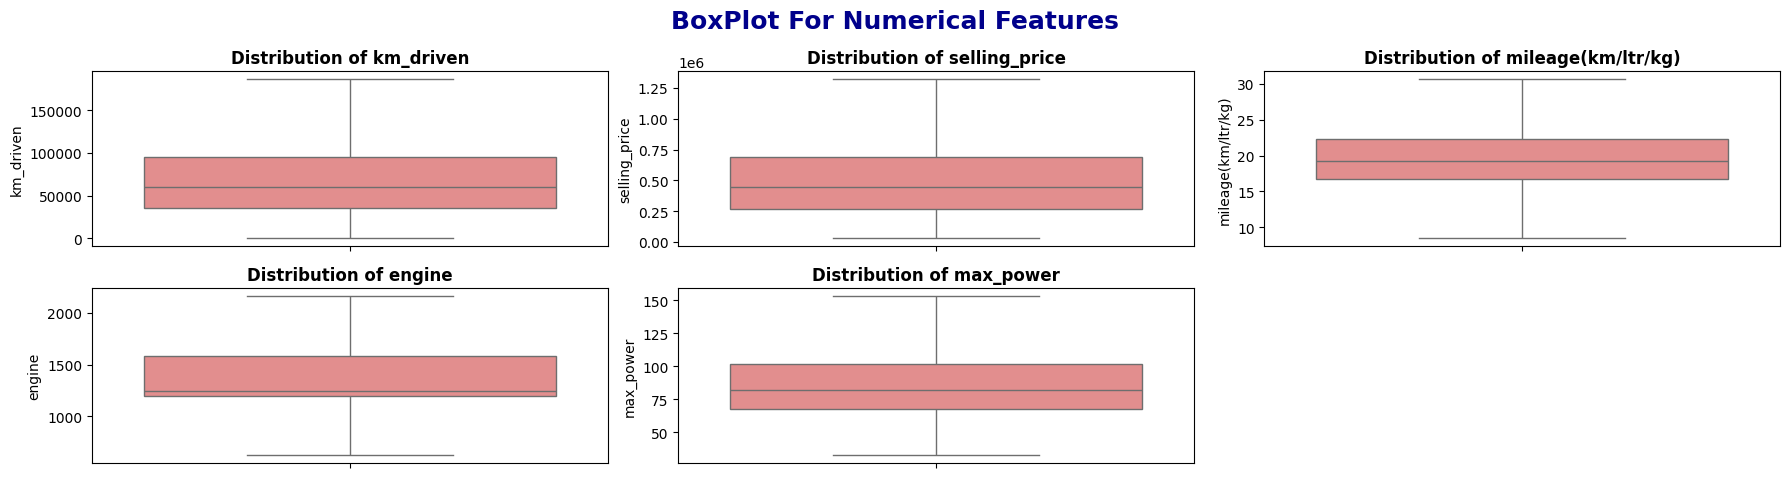

In [19]:
fig , axes = plt.subplots(n_rows,n_cols,figsize = (18,7))
axes = axes.flatten()
plt.suptitle('BoxPlot For Numerical Features',fontsize=18,fontweight = 'bold',color = 'darkblue')
for i,col in enumerate(cap_features):
    sns.boxplot(y= data[col],ax=axes[i],color='lightcoral')
    axes[i].set_title(f"Distribution of {col}",fontsize=12,fontweight='bold')
    for j in range(len(cap_features),len(axes)):
            axes[j].set_visible(False)
plt.tight_layout()

**Inferance**
- **Outliers are capped properly**

## **Feature engineering**

Changing `year` feature to `car_age`

In [20]:
from datetime import datetime

current_year = datetime.now().year
data['car_age'] = current_year - data['year']
# changing data type float to year.'

data['car_age'] = data['car_age'].astype('int8')

# drop year column.
data.drop(columns='year',inplace=True)

In [21]:
data.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age
0,Maruti,450000.0,145500.0,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5,12
1,Skoda,370000.0,120000.0,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5,12
2,Honda,158000.0,140000.0,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5,20
3,Hyundai,225000.0,127000.0,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5,16
4,Maruti,130000.0,120000.0,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5,19


In [22]:
# changing data type float ----> int

data['km_driven'] = data['km_driven'].astype('int64')
data[['selling_price','seats','engine']] = data[['selling_price','seats','engine']].astype('int64')

In [23]:
data.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5,12
1,Skoda,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5,12
2,Honda,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,5,20
3,Hyundai,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5,16
4,Maruti,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5,19


## **Checking Linearity Of Data**

In [24]:
num_features = data.select_dtypes(include=['number']).columns.to_list()

In [25]:
num_features

['selling_price',
 'km_driven',
 'mileage(km/ltr/kg)',
 'engine',
 'max_power',
 'seats',
 'car_age']

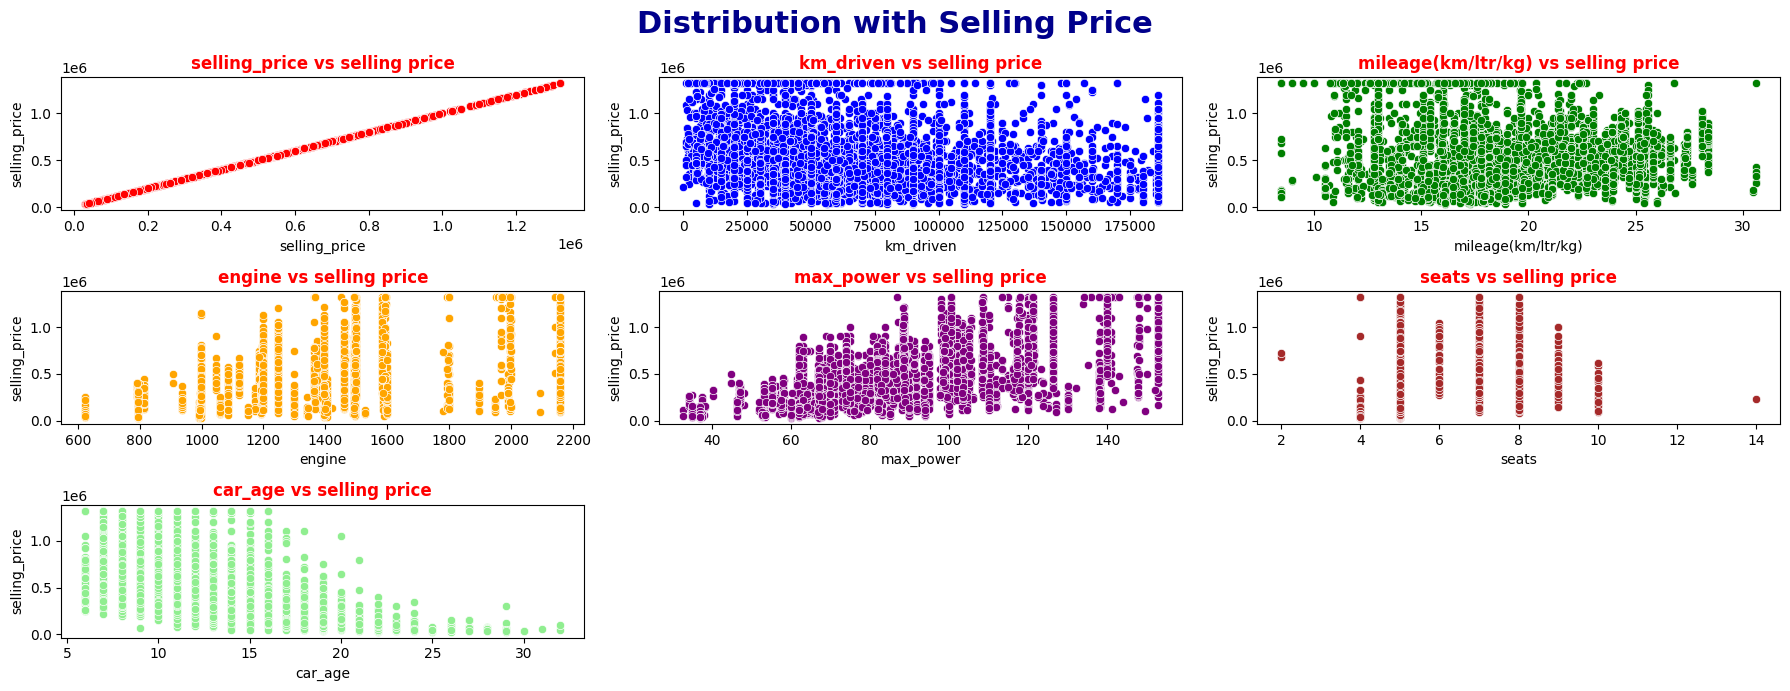

In [26]:
fig , axes = plt.subplots(n_rows,n_cols,figsize = (18,7))
color = ['red','blue','green','orange','purple','brown','lightgreen']
axes = axes.flatten()
plt.suptitle(f'Distribution with Selling Price',fontsize=22,fontweight = 'bold',color = 'darkblue')
for i,col in enumerate(num_features):
    sns.scatterplot(x=data[col],y=data['selling_price'],ax = axes[i],color = color[i])
    axes[i].set_title(f'{col} vs selling price',fontsize=12,fontweight= 'bold',color ='red')
    for j in range(len(num_features),len(axes)):
        axes[j].set_visible(False)
plt.tight_layout()

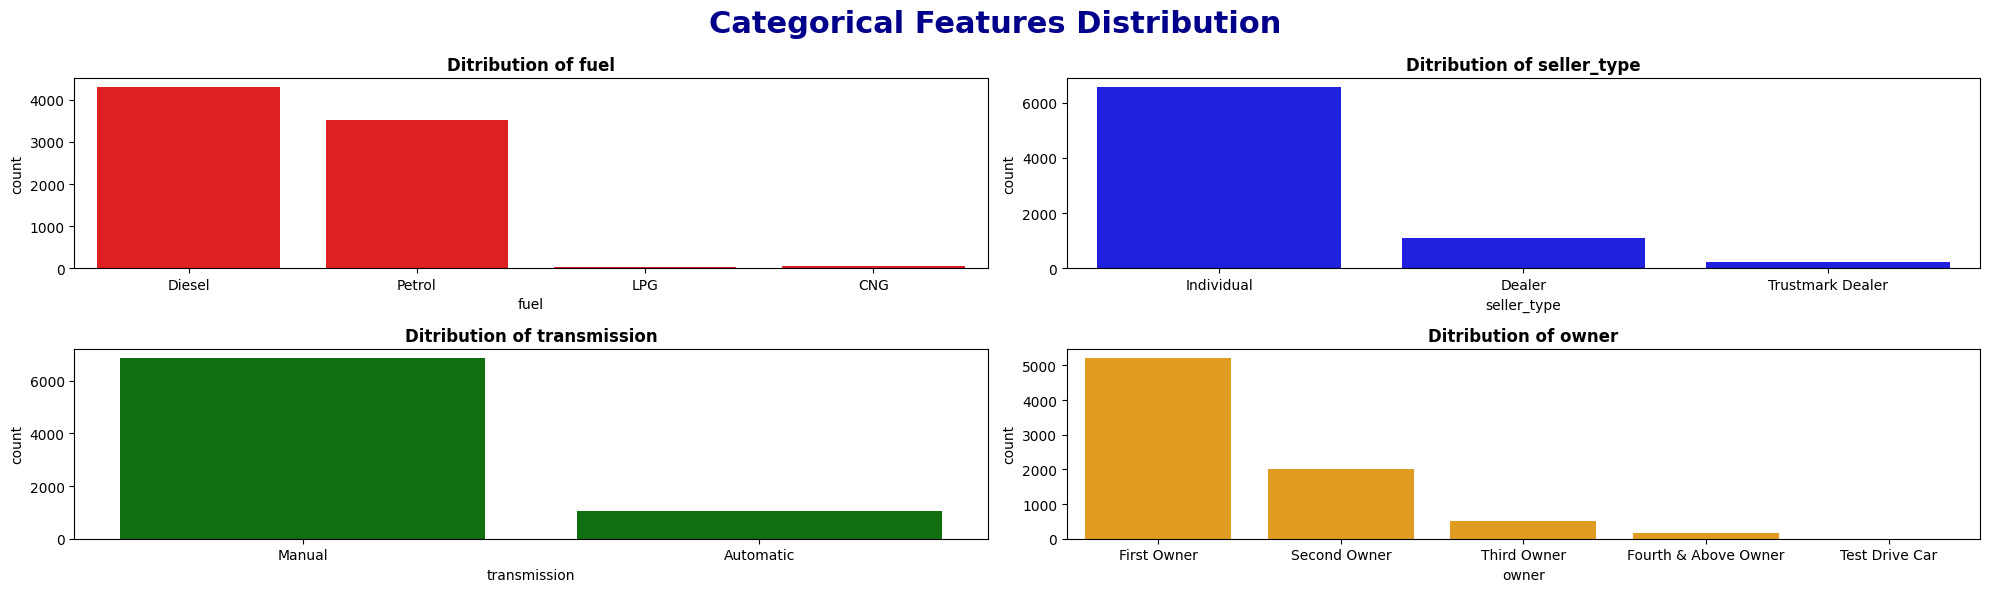

In [27]:
# checking for distribution(Kde Plot)
fig , axes = plt.subplots(2,2,figsize=(20,6))
axes = axes.flatten()
color = ['red','blue','green','orange','purple','brown']
plt.suptitle('Categorical Features Distribution',fontsize = 22,fontweight='bold',color = 'darkblue')
for i , col in enumerate(cat_features):
    sns.countplot(data= data,x=col,ax = axes[i],color=color[i])
    axes[i].set_title(f'Ditribution of {col}',fontsize=12,fontweight= 'bold')

plt.tight_layout()

**sum category are to much low changing them in other/higher**

In [28]:
# name feature
top_brands = data['name'].value_counts().head(10).index.to_list()
data['name'] = np.where(data['name'].isin(top_brands),data['name'],'Others')

# fuel 
'''Since only Diseal and petrol are most, 
while LPG and CNG are least merge them and categories as other'''

fuel_category = data['fuel'].value_counts().head(2).index.to_list()
data['fuel'] = np.where(data['fuel'].isin(fuel_category),data['fuel'],'Other')

# owner
owner_type = data['owner'].value_counts().head(2).index.to_list()
data['owner'] = np.where(data['owner'].isin(owner_type),data['owner'],'Higher')

# seller type
seller_type = data['seller_type'].value_counts().head(1).index.to_list()
data['seller_type'] = np.where(data['seller_type'].isin(seller_type),data['seller_type'],'Dealer')

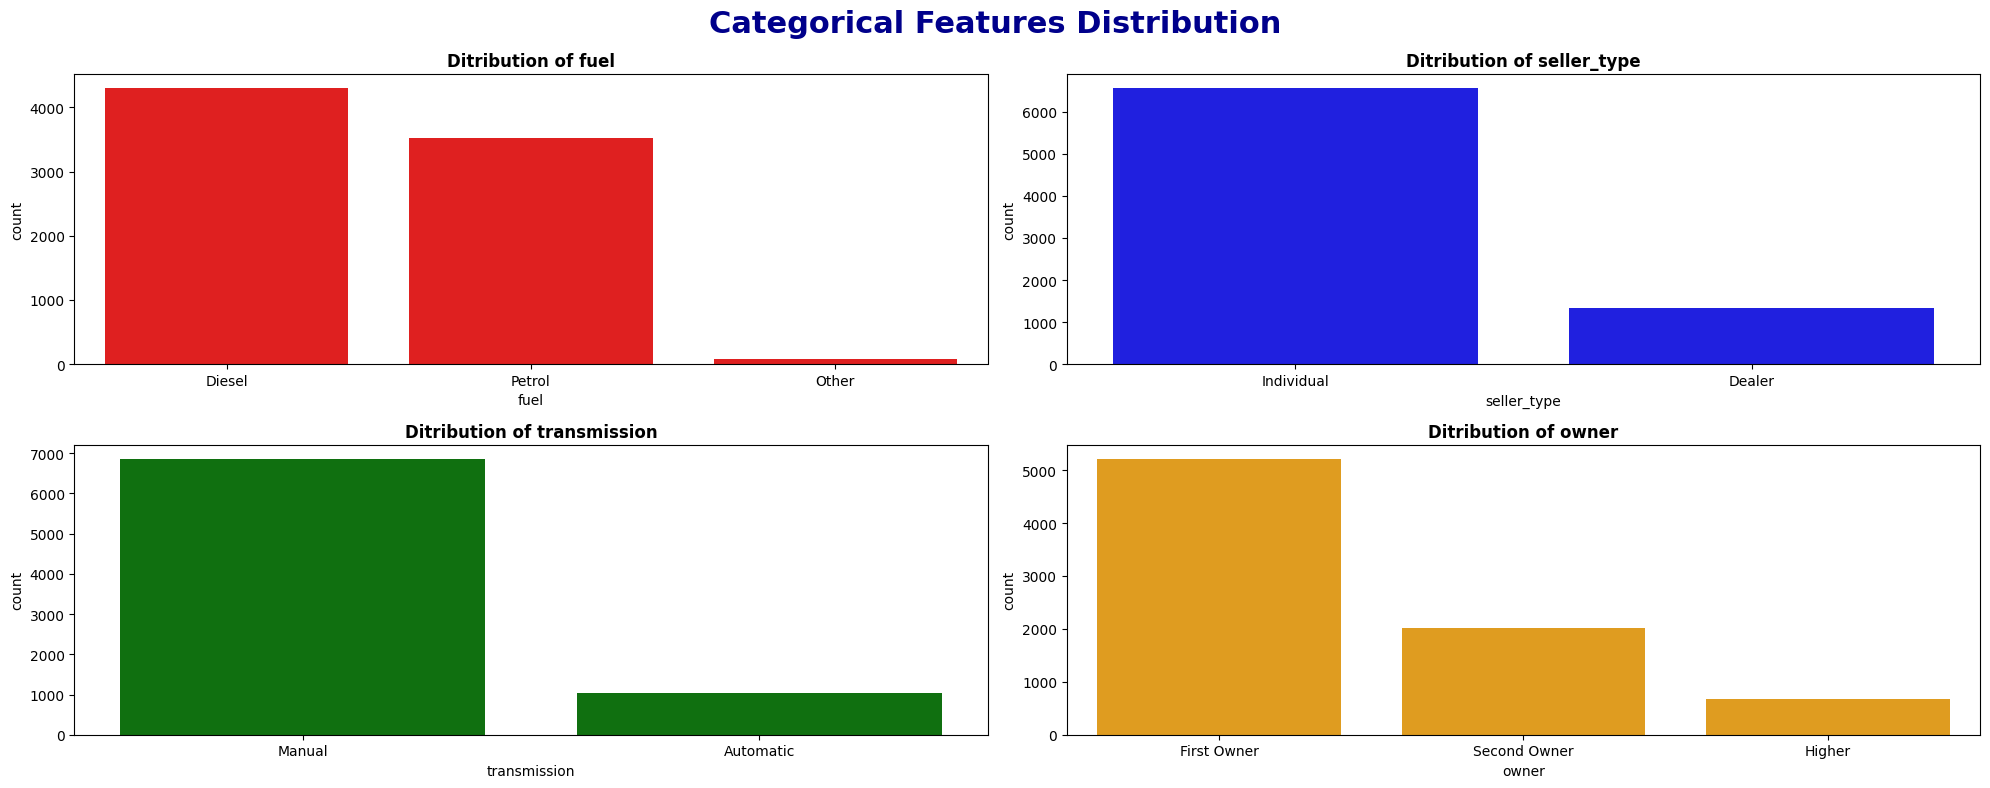

In [29]:
# after changing
fig , axes = plt.subplots(2,2,figsize=(20,8))
axes = axes.flatten()
color = ['red','blue','green','orange','purple','brown']
plt.suptitle('Categorical Features Distribution',fontsize = 22,fontweight='bold',color = 'darkblue')
for i , col in enumerate(cat_features):
    sns.countplot(data= data,x=col,ax = axes[i],color=color[i])
    axes[i].set_title(f'Ditribution of {col}',fontsize=12,fontweight= 'bold')

plt.tight_layout()

In [30]:
data.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5,12
1,Others,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5,12
2,Honda,158000,140000,Petrol,Individual,Manual,Higher,17.70,1497,78.00,5,20
3,Hyundai,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5,16
4,Maruti,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5,19


In [31]:
data['seats'].unique()

array([ 5,  4,  7,  8,  6,  9, 10, 14,  2])

Text(0.5, 1.0, 'Correlation Matrix')

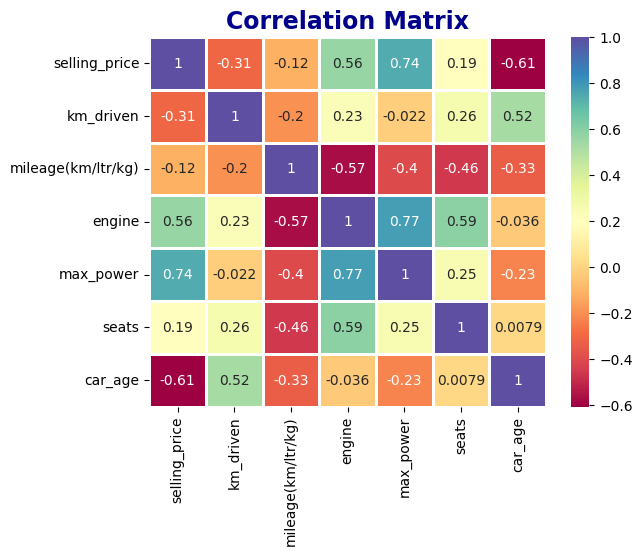

In [32]:
## checking collinearity
numeric_df = data.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),annot=True,cmap='Spectral',linewidths=0.9)
plt.title('Correlation Matrix',fontdict=dict(fontsize = 17,fontweight = 'bold'),color= 'darkblue')

In [33]:
# saving cleaned data
data.to_csv('Cleaned car data.csv')

# **Splitting data in x and y**

In [34]:
x = data.drop(columns = ['selling_price'])
y = data['selling_price']

In [35]:
x.head()

,name,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age
0,Maruti,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5,12
1,Others,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5,12
2,Honda,140000,Petrol,Individual,Manual,Higher,17.70,1497,78.00,5,20
3,Hyundai,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5,16
4,Maruti,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5,19


In [36]:
y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

### **pipeline**

In [37]:
num_features = x.select_dtypes(include='number').columns.to_list()

In [77]:
preprocessor = ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(handle_unknown='ignore'),['name','fuel','seller_type','transmission']),
    ('oe',OrdinalEncoder(categories=[['Higher','Second Owner','First Owner']]),['owner']),
    ('scaler',StandardScaler(),num_features)
],remainder='passthrough')

## **splitting data in training and testing**

In [78]:
x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
print('shape of training data: ',x_train.shape)
print('shape of testing data: ',x_test.shape)

shape of training data:  (6324, 11)
shape of testing data:  (1582, 11)


In [ ]:
pipe_lr = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [70]:
pipe_lr.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('oe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [71]:
y_pred = pipe_lr.predict(x_test)

In [84]:
y_pred

array([ 542785.57426251,  503628.22785717,  123809.84295461, ...,
        291489.23653685, 1292740.52774345,  629257.23251335],
      shape=(1582,))

In [72]:
print('R2 Score: ',r2_score(y_test,y_pred)*100)
print("RMSE: ",root_mean_squared_error(y_test,y_pred))
print('MAE: ',mean_absolute_error(y_test,y_pred))

R2 Score:  83.13396129539117
RMSE:  137742.5585390151
MAE:  104452.05958922922


In [75]:
name_list = x.columns.to_list()

In [76]:
pipe_lr.predict(pd.DataFrame([['Maruti',120000,'Petrol','Individual','Manual','Higher',21.14,1396,103.52,6,12]],columns=name_list))

array([435053.11451772])

> ## **Final Inference (Linear Regression):**
- `Model Performance`: The Linear Regression model achieved an R² score of 83.13%, explaining 83.13% of the variance in the target variable.<br><br>
- `Limitation`: Despite a decent R² score, the RMSE was significantly high. This is due to the presence of extreme high values (luxury cars) in the target variable, which heavily influenced the regression line.<br><br>
- `Attempted Fix`: We applied a Log Transformation to the target variable. While it improved the statistical score, it complicated the business interpretability (predicting log prices is not intuitive for end-users).<br><br>

- `Next Steps / Improvement`: To handle non-linear relationships and outliers without losing business interpretability, we will transition
to a tree-based model (Decision Tree). Additionally, Decision Trees are invariant to feature scaling, simplifying our preprocessing pipeline.

## **Model 2 Decision Trees**

In [57]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [ ]:
## finding optimal depth of decision tree
scores_test = []
scores_train = []
for depth in range(1,20):
    pipe_dt = Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('model',DecisionTreeRegressor(max_depth=depth,random_state=42))
    ])

    pipe_dt.fit(x_train,y_train)
    y_pred_dt = pipe_dt.predict(x_test)
    y_pred_train = pipe_dt.score(x_train,y_train)
    R2_score_test = r2_score(y_test,y_pred_dt)
    scores_test.append(R2_score_test)
    scores_train.append(y_pred_train)

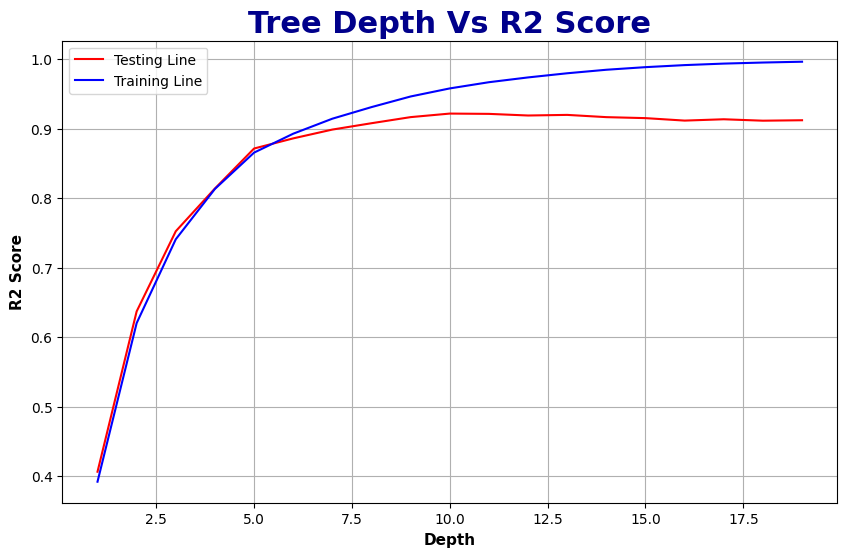

In [ ]:
# finding optimal max-depth 
plt.figure(figsize=(10,6))
plt.plot(range(1,20),scores_test,color='red',label= 'Testing Line')
plt.plot(range(1,20),scores_train,color='blue',label = 'Training Line')
plt.title('Tree Depth Vs R2 Score',fontdict= dict(fontweight='bold',fontsize = 22),color = 'darkblue')
plt.xlabel('Depth',fontdict= dict(fontweight='bold',fontsize = 11))
plt.ylabel('R2 Score',fontdict= dict(fontweight='bold',fontsize = 11))
plt.grid()
plt.legend()

## **Inferance**:
- below 5 model our model start underfitting.
- After depth 6 model starts overfit,While 7 is optimal one. 

In [121]:
pipe_dt = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',DecisionTreeRegressor(max_depth=7,random_state=42))
])

In [122]:
pipe_dt.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('oe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [124]:
print('RMSE: ',root_mean_squared_error(y_test,y_pred_dt))
print('MAE: ',mean_absolute_error(y_test,y_pred_dt))
print('R2 Score: ',r2_score(y_test,y_pred_dt))

RMSE:  99423.37692863362
MAE:  60152.1269490097
R2 Score:  0.9121273302869034


In [128]:
y_pred_train = pipe_dt.score(x_train,y_train)
print('R2 Score Training : ',y_pred_train)

R2 Score Training :  0.9141920860585793


## **📝 Final Inference: Decision Tree Regressor**
- **Model Selection & Improvement**: To overcome the limitations of Linear Regression (which struggled with the<br>non-linear relationships and high-value outliers in car prices), we implemented a Decision Tree Regressor. Unlike linear models, Decision Trees naturally handle non-linear data and are invariant to feature scaling.<br>
- **Addressing Overfitting**: The initial default Decision Tree showed signs of severe overfitting, achieving a Training R² of 99.7% but dropping to 91.3% on the test set. The model was memorizing the training data rather than learning general patterns.<br>
- **Hyperparameter Tuning**: To fix this, we plotted a Validation Curve (Tree Depth vs. R² Score) to find the optimal complexity. We identified  max_depth=7  as the sweet spot where the model captures the underlying patterns without memorizing noise.<br>
- **Final Performance**: After tuning, the model achieved a highly generalized performance:
1. Training R²: 91.41%
2. Testing R²: 91.21%
3. RMSE: ~99,423 | MAE: ~60,152
- **Conclusion**: The overfitting gap was successfully reduced from 8.4% to just 0.2%. This tuned Decision Tree provides a robust, highly accurate, and interpretable solution for predicting car prices, making it ready for deployment in our Streamlit application.

In [129]:
# dumping the model
joblib.dump(pipe_dt,'car_price_prediction_model_dt.pkl')

['car_price_prediction_model_dt.pkl']